## 1. Import Libraries


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from xgboost import XGBRegressor


## 2. Load Dataset


In [14]:
df = pd.read_csv("../data/raw/ames_housing.csv")
df.head()


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


## 3. Separate Features and Target


In [15]:
X = df.drop("SalePrice", axis=1)
y = df["SalePrice"]

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (2930, 81)
y shape: (2930,)


## 4. Identify Numerical and Categorical Features


In [16]:
numerical_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "string"]).columns.tolist()

print("Number of numerical features:", len(numerical_features))
print("Number of categorical features:", len(categorical_features))


Number of numerical features: 38
Number of categorical features: 43


## 5. Train-Test Split


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (2344, 81)
X_test shape: (586, 81)
y_train shape: (2344,)
y_test shape: (586,)


## 6. Build Preprocessing Pipelines


In [18]:
numerical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numerical_transformer, numerical_features),
    ("cat", categorical_transformer, categorical_features)
])


> **نکته:**  
> برای مدل‌های tree-based مثل XGBoost هم `StandardScaler` ضروری نیست،  
> ولی فعلاً برای یکدست بودن pipeline آن را نگه می‌داریم.


## 7. Create XGBoost Pipeline


In [19]:
xgb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    ))
])


## 8. Train the Model


In [20]:
xgb_model.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](81,)","['Order','PID','MS SubClass',...,'Yr Sold','Sale Type','Sale Condition']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,81
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of column

## 9. Make Predictions


In [21]:
y_pred = xgb_model.predict(X_test)

print("Prediction shape:", y_pred.shape)


Prediction shape: (586,)


## 10. Evaluate the Model


In [22]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("MAE:", mae)
print("R2 Score:", r2)


RMSE: 23286.025337098643
MAE: 14340.7265625
R2 Score: 0.9323684573173523


## 11. Actual vs Predicted


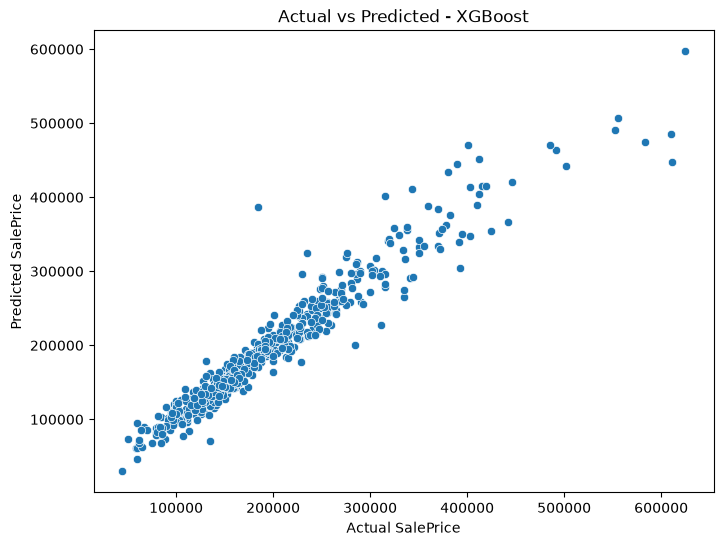

In [23]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")
plt.title("Actual vs Predicted - XGBoost")
plt.show()


## 12. Error Distribution


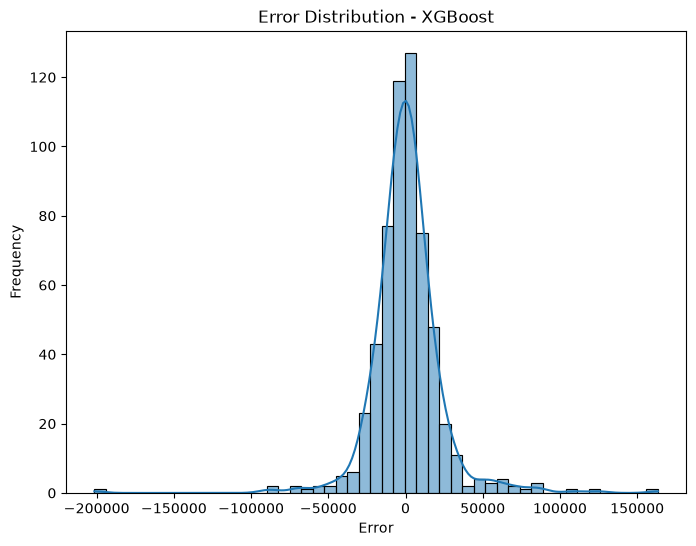

In [24]:
errors = y_test - y_pred

plt.figure(figsize=(8, 6))
sns.histplot(errors, kde=True)
plt.title("Error Distribution - XGBoost")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.show()


## 13. XGBoost Model Summary


### XGBoost Results
- مدل `XGBRegressor` آموزش داده شد.
- preprocessing مشابه مراحل قبل روی داده‌ها اعمال شد.
- عملکرد مدل با معیارهای `RMSE`، `MAE` و `R2 Score` ارزیابی شد.
- نمودار `Actual vs Predicted` برای بررسی کیفیت پیش‌بینی رسم شد.
- نمودار `Error Distribution` برای تحلیل خطاها رسم شد.
- این نتایج با مدل‌های `Linear Regression` و `Random Forest` مقایسه خواهند شد.


## 14. Feature Importance Extraction


In [25]:
# 1. استخراج نام ستون‌ها بعد از پیش‌پردازش (One-Hot Encoding)
ohe_cols = (
    xgb_model.named_steps["preprocessor"]
    .named_transformers_["cat"]
    .named_steps["onehot"]
    .get_feature_names_out(categorical_features)
)

# ترکیب نام ستون‌های عددی و ستون‌های ساخته شده با One-Hot
all_features = numerical_features + list(ohe_cols)

# 2. استخراج میزان اهمیت ویژگی‌ها از مدل آموزش دیده
importances = xgb_model.named_steps["model"].feature_importances_

# 3. ساخت دیتافریم برای مرتب‌سازی راحت‌تر
feature_importance_df = pd.DataFrame({
    "Feature": all_features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

# نمایش 15 ویژگی برتر
feature_importance_df.head(15)


,Feature,Importance
5,Overall Qual,0.206390
27,Garage Cars,0.111211
237,Kitchen Qual_Gd,0.043113
260,Garage Finish_Unf,0.041820
123,House Style_2Story,0.039956
235,Kitchen Qual_Ex,0.036703
191,Bsmt Qual_Ex,0.033453
17,Gr Liv Area,0.030472
20,Full Bath,0.027499
44,MS Zoning_RM,0.021372


## 15. Plot Top 15 Feature Importances


C:\Users\alir\AppData\Local\Temp\ipykernel_15592\290253098.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


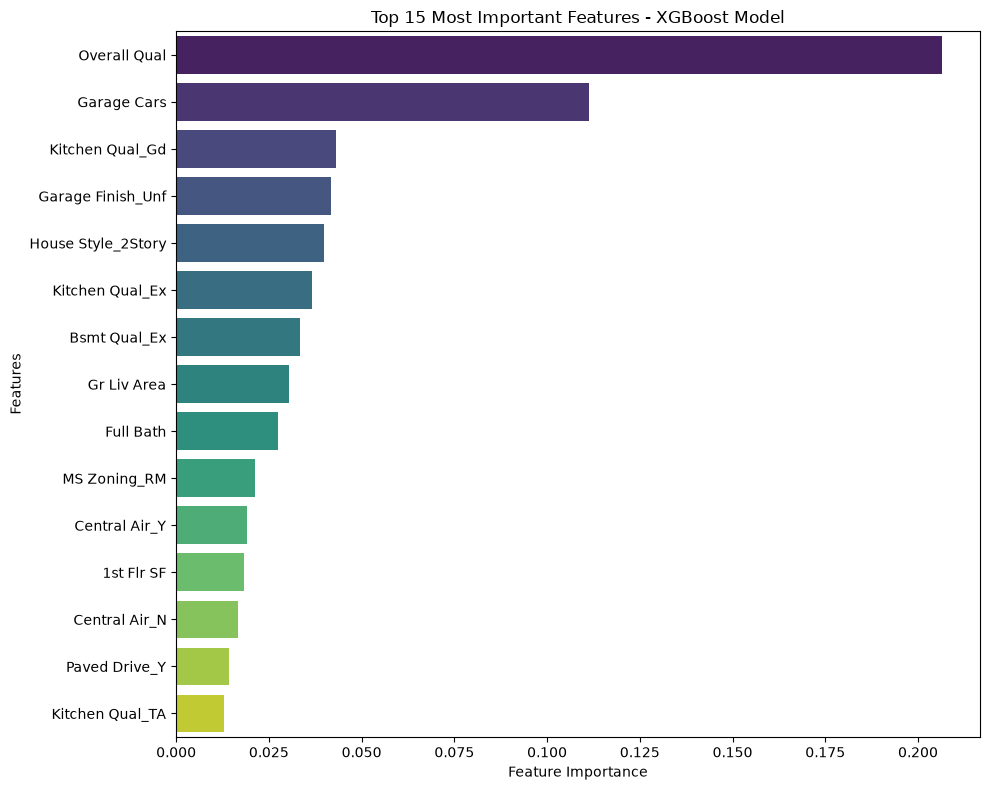

In [26]:
plt.figure(figsize=(10, 8))
sns.barplot(
    x="Importance", 
    y="Feature", 
    data=feature_importance_df.head(15), 
    palette="viridis"
)
plt.title("Top 15 Most Important Features - XGBoost Model")
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.tight_layout()
plt.savefig("../reports/figures/xgboost_feature_importance.png", dpi=300)
plt.show()


## 16. Feature Importance Summary


### یافته‌های کلیدی اهمیت ویژگی‌ها:
- نمودار بالا اهمیت ویژگی‌ها را پس از انجام پیش‌پردازش و One-Hot Encoding نمایش می‌دهد.
- این نمودار به صورت خودکار در مسیر `reports/figures/` ذخیره شد تا در گزارش نهایی پروژه استفاده شود.
